# 41.3 · Missing modalities and synchronization

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain missing modalities and synchronization using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[16 · Camera and Calibration](../../16-camera-and-calibration/README.md), [35 · Optical Flow](../../35-optical-flow/README.md), [40 · Vision-Language Models](../../40-vision-language-models/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Multimodal vision combines information from different sources, such as RGB, depth, text or audio. The central problems include alignment, missing inputs and conflicting evidence. More sensors can improve a system only when their uncertainties and timing are handled correctly.

## 2. Intuition

A missing modality should trigger an explicit fallback, not a fabricated zero measurement. Timestamp misalignment can turn useful depth or audio into contradictory evidence. Evaluate performance with dropped, delayed and corrupted modalities so the system does not rely silently on ideal sensor availability.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 41
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\hat x=(x_1/\sigma_1^2+x_2/\sigma_2^2)/(1/\sigma_1^2+1/\sigma_2^2)
$$

x1,x2 estimate one quantity and σ1²,σ2² are independent measurement variances. Measurements 2 and 4 with variances 1 and 4 combine to 2.4, closer to the more precise first sensor.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
x1, x2, variance1, variance2 = 2.0, 4.0, 1.0, 4.0
fused = (x1 / variance1 + x2 / variance2) / (1 / variance1 + 1 / variance2)
assert np.isclose(fused, 2.4)
print(fused)

2.4


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab generates visual and depth-like scalar measurements, applies precision weighting and falls back to the available sensor when depth is missing. It isolates fusion rather than a full learned multimodal architecture.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def multimodal(lesson=0, seed=42, amount=1.0):
    rng = np.random.default_rng(seed)
    truth = rng.integers(0, 2, 160)
    visual = truth + rng.normal(0, 0.55 * amount, len(truth))
    depth = truth + rng.normal(0, 0.35, len(truth))
    present = rng.random(len(truth)) > (0.35 if lesson else 0)
    # Precision-weighted fusion assumes conditionally independent Gaussian errors.
    wv, wd = 1 / (0.55 * amount) ** 2, 1 / 0.35**2
    fused = (wv * visual + wd * depth * present) / (wv + wd * present)
    return Result(
        "41 · Sensor fusion and missing modalities",
        curves={
            "Visual signal": visual[:40],
            "Depth signal": depth[:40],
            "Fused signal": fused[:40],
        },
        metrics={
            "visual_accuracy": float(((visual > 0.5) == truth).mean()),
            "fusion_accuracy": float(((fused > 0.5) == truth).mean()),
            "missing_depth": int((~present).sum()),
        },
        notes="Generated binary labels and noisy scalar sensor readings. Precision weights use known synthetic noise; real systems must estimate uncertainty on held-out data and synchronize timestamps. Text-image learning is in Chapter 40.",
    )

{
  "visual_accuracy": 0.86875,
  "fusion_accuracy": 0.95,
  "missing_depth": 59
}
Generated binary labels and noisy scalar sensor readings. Precision weights use known synthetic noise; real systems must estimate uncertainty on held-out data and synchronize timestamps. Text-image learning is in Chapter 40.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import softmax

display(Code(inspect.getsource(softmax), language="python"))

def softmax(values, axis=-1):
    values = np.asarray(values, float)
    exp = np.exp(values - values.max(axis=axis, keepdims=True))
    return exp / exp.sum(axis=axis, keepdims=True)

## 8. Experiment

Make sensor errors correlated and compare the theoretical confidence with observed error. Then introduce missing depth.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "visual_accuracy": 0.86875,
    "fusion_accuracy": 0.95,
    "missing_depth": 59
  },
  "second_seed": {
    "visual_accuracy": 0.80625,
    "fusion_accuracy": 0.93125,
    "missing_depth": 59
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

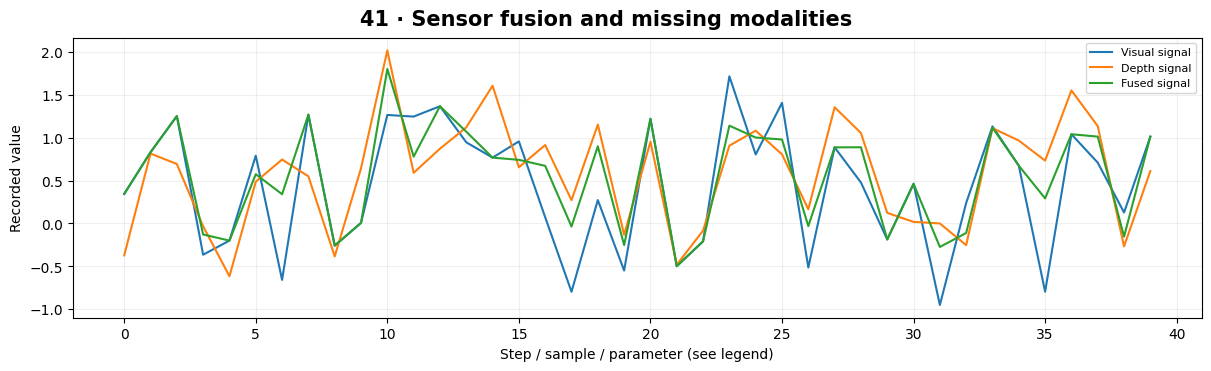

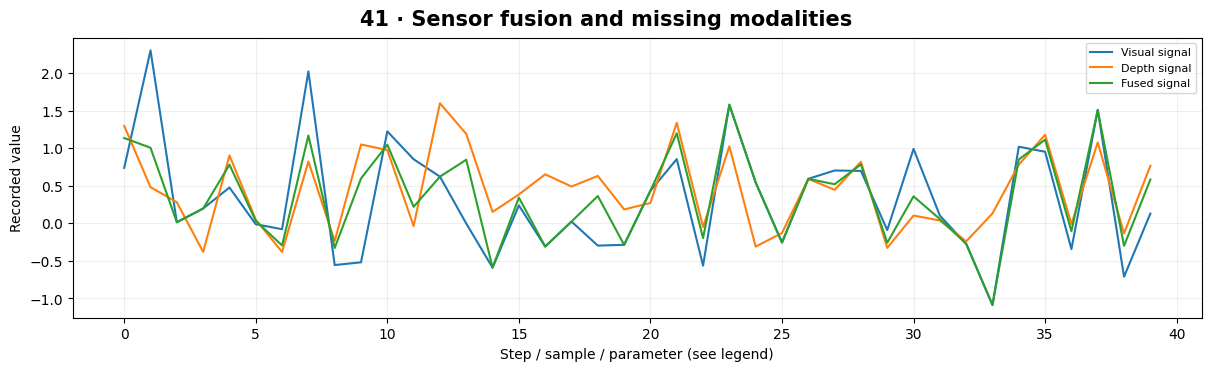

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **RGB and Sensor Fusion Lab**. Combine visual and nonvisual observations without hiding missing data. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Concatenating arrays is not sufficient if modalities describe different times or coordinates. A high-confidence sensor can still be systematically biased.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Make sensor errors correlated and compare the theoretical confidence with observed error. Then introduce missing depth.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Design an RGB-depth inspection pipeline that detects stale measurements and evaluates with one sensor disabled.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A missing modality should trigger an explicit fallback, not a fabricated zero measurement. Timestamp misalignment can turn useful depth or audio into contradictory evidence. Evaluate performance with dropped, delayed and corrupted modalities so the system does not rely silently on ideal sensor availability.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[42 · Generative Computer Vision](../../42-generative-computer-vision/README.md)

[Primary reference](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)